# Proyecto final: análisis operativo de taxis en Nueva York

El objetivo de este proyecto es analizar los principales factores asociados a la variación de la demanda y del valor económico de los trayectos de taxi en Nueva York. Para ello, se integran datos de viajes y datos meteorológicos con el fin de estudiar patrones temporales y geográficos, segmentar zonas con comportamientos distintos y evaluar en qué medida ciertas condiciones externas actúan como contexto operativo, y no como explicación única del fenómeno.

## 1. Importación de librerías y configuración del notebook

En esta sección se importan las librerías necesarias y se ajustan algunas opciones de visualización para trabajar de forma más cómoda con tablas y resúmenes.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import pyarrow
import matplotlib.pyplot as plt

# opciones de visualización
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.float_format", "{:,.2f}".format)

## 2. Carga de datos de taxi

Carga de muestra mensual del dataset de taxis para validar la estructura de los datos, comprobar los tipos de variables y definir el flujo de limpieza antes de procesar el año completo.

In [2]:
# rutas
data_dir = Path("data/raw/taxi")
sample_file = data_dir / "yellow_tripdata_2024-01.parquet"

# columnas mínimas del dataset de taxis
taxi_cols = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "trip_distance",
    "payment_type",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "Airport_fee"
]

# carga de muestra
df_taxi = pd.read_parquet(sample_file, columns=taxi_cols)

print("shape:", df_taxi.shape)
print("\ncolumnas:\n", df_taxi.columns.tolist())
print("\ndtypes:\n", df_taxi.dtypes)
print("\nhead:\n", df_taxi.head())

shape: (2964624, 10)

columnas:
 ['tpep_pickup_datetime', 'tpep_dropoff_datetime', 'PULocationID', 'DOLocationID', 'trip_distance', 'payment_type', 'fare_amount', 'tip_amount', 'total_amount', 'Airport_fee']

dtypes:
 tpep_pickup_datetime     datetime64[us]
tpep_dropoff_datetime    datetime64[us]
PULocationID                      int32
DOLocationID                      int32
trip_distance                   float64
payment_type                      int64
fare_amount                     float64
tip_amount                      float64
total_amount                    float64
Airport_fee                     float64
dtype: object

head:
   tpep_pickup_datetime tpep_dropoff_datetime  PULocationID  DOLocationID  trip_distance  payment_type  fare_amount  tip_amount  \
0  2024-01-01 00:57:55   2024-01-01 01:17:43           186            79           1.72             2        17.70        0.00   
1  2024-01-01 00:03:00   2024-01-01 00:09:36           140           236           1.80             

## 3. Validación inicial y preparación básica del dataset de taxis

En esta fase se convierten las variables temporales, generamos algunos campos derivados y se realiza una primera limpieza conservadora para eliminar registros claramente no válidos sin perder demasiada información útil.

In [3]:
# copia de trabajo
df = df_taxi.copy()

# conversión de fechas
df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# variables temporales derivadas
df["trip_duration_min"] = (
    (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
)

df["pickup_hour"] = df["tpep_pickup_datetime"].dt.floor("h")
df["pickup_date"] = df["tpep_pickup_datetime"].dt.date
df["pickup_weekday"] = df["tpep_pickup_datetime"].dt.day_name()
df["pickup_month"] = df["tpep_pickup_datetime"].dt.month
df["pickup_dayofweek"] = df["tpep_pickup_datetime"].dt.dayofweek
df["pickup_hour_num"] = df["tpep_pickup_datetime"].dt.hour
df["is_weekend"] = df["pickup_dayofweek"].isin([5, 6]).astype(int)

# limpieza inicial conservadora
df = df[
    (df["PULocationID"] > 0) &
    (df["DOLocationID"] > 0) &
    (df["trip_distance"] > 0) &
    (df["trip_distance"] <= 100) &
    (df["fare_amount"] > 0) &
    (df["fare_amount"] <= 500) &
    (df["total_amount"] > 0) &
    (df["total_amount"] <= 500) &
    (df["trip_duration_min"] > 0) &
    (df["trip_duration_min"] <= 180)
].copy()

print("shape limpio:", df.shape)
print("\nnulls:\n", df.isna().sum())
print("\nresumen numérico:\n", df[[
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "trip_duration_min",
    "Airport_fee"
]].describe())
print("\npayment_type:\n", df["payment_type"].value_counts(dropna=False).sort_index())
print("\nPULocationID únicos:", df["PULocationID"].nunique())
print("DOLocationID únicos:", df["DOLocationID"].nunique())

shape limpio: (2867582, 18)

nulls:
 tpep_pickup_datetime          0
tpep_dropoff_datetime         0
PULocationID                  0
DOLocationID                  0
trip_distance                 0
payment_type                  0
fare_amount                   0
tip_amount                    0
total_amount                  0
Airport_fee              115172
trip_duration_min             0
pickup_hour                   0
pickup_date                   0
pickup_weekday                0
pickup_month                  0
pickup_dayofweek              0
pickup_hour_num               0
is_weekend                    0
dtype: int64

resumen numérico:
        trip_distance  fare_amount   tip_amount  total_amount  trip_duration_min  Airport_fee
count   2,867,582.00 2,867,582.00 2,867,582.00  2,867,582.00       2,867,582.00 2,752,410.00
mean            3.29        18.48         3.40         27.33              14.96         0.15
std             4.37        17.03         3.83         21.54              1

## 4. Carga y preparación inicial del dataset meteorológico

A continuación se seleccionan únicamente las variables meteorológicas relevantes para el análisis, se transforman los tipos de datos y se generan campos auxiliares como la hora, la lluvia y la variable de oscuridad.

In [4]:
# ruta
weather_file = Path("data/raw/weather/LCD_USW00094728_2024.csv")

# columnas seleccionadas
weather_cols = [
    "DATE",
    "HourlyDryBulbTemperature",
    "HourlyPrecipitation",
    "HourlyVisibility",
    "HourlyWindSpeed",
    "Sunrise",
    "Sunset",
    "HourlyPresentWeatherType"
]

# carga
wx = pd.read_csv(weather_file, usecols=weather_cols).copy()

# fechas
wx["DATE"] = pd.to_datetime(wx["DATE"])
wx["weather_hour"] = wx["DATE"].dt.floor("h")
wx["weather_date"] = wx["DATE"].dt.normalize()

# conversión numérica conservadora
num_cols = [
    "HourlyDryBulbTemperature",
    "HourlyPrecipitation",
    "HourlyVisibility",
    "HourlyWindSpeed",
    "Sunrise",
    "Sunset"
]

for col in num_cols:
    wx[col] = pd.to_numeric(wx[col], errors="coerce")

# función para convertir hhmm a minutos
def hhmm_to_minutes(x):
    if pd.isna(x):
        return np.nan
    x = int(x)
    hh = x // 100
    mm = x % 100
    return hh * 60 + mm

wx["sunrise_min"] = wx["Sunrise"].apply(hhmm_to_minutes)
wx["sunset_min"] = wx["Sunset"].apply(hhmm_to_minutes)

# completar sunrise/sunset dentro de cada día
wx["sunrise_min"] = wx.groupby("weather_date")["sunrise_min"].transform("first")
wx["sunset_min"] = wx.groupby("weather_date")["sunset_min"].transform("first")

# minuto del día
wx["minute_of_day"] = wx["DATE"].dt.hour * 60 + wx["DATE"].dt.minute

# indicador de oscuridad
wx["is_dark"] = (
    (wx["minute_of_day"] < wx["sunrise_min"]) |
    (wx["minute_of_day"] > wx["sunset_min"])
).astype("Int64")

# variables meteorológicas básicas
wx["rain_mm"] = wx["HourlyPrecipitation"].fillna(0)
wx["rain_flag"] = (wx["rain_mm"] > 0).astype("Int64")

# renombrado
wx = wx.rename(columns={
    "HourlyDryBulbTemperature": "temp_c",
    "HourlyVisibility": "visibility",
    "HourlyWindSpeed": "wind_speed",
    "HourlyPresentWeatherType": "weather_type_raw"
})

print("shape:", wx.shape)
print("\nnulls:\n", wx[[
    "DATE", "weather_hour", "temp_c", "rain_mm", "visibility",
    "wind_speed", "sunrise_min", "sunset_min",
    "is_dark", "weather_type_raw"
]].isna().sum())

print("\ndtypes:\n", wx[[
    "DATE", "weather_hour", "temp_c", "rain_mm", "visibility",
    "wind_speed", "sunrise_min", "sunset_min",
    "is_dark"
]].dtypes)

print("\nhead:\n", wx[[
    "DATE", "weather_hour", "temp_c", "rain_mm", "visibility",
    "wind_speed", "sunrise_min", "sunset_min",
    "is_dark", "weather_type_raw"
]].head(15))

shape: (11608, 16)

nulls:
 DATE                   0
weather_hour           0
temp_c               421
rain_mm                0
visibility           435
wind_speed          1466
sunrise_min            0
sunset_min             0
is_dark                0
weather_type_raw    8833
dtype: int64

dtypes:
 DATE            datetime64[us]
weather_hour    datetime64[us]
temp_c                 float64
rain_mm                float64
visibility             float64
wind_speed             float64
sunrise_min            float64
sunset_min             float64
is_dark                  Int64
dtype: object

head:
                   DATE        weather_hour  temp_c  rain_mm  visibility  wind_speed  sunrise_min  sunset_min  is_dark weather_type_raw
0  2024-01-01 00:00:00 2024-01-01 00:00:00     NaN     0.00         NaN         NaN       440.00      998.00        1              NaN
1  2024-01-01 00:51:00 2024-01-01 00:00:00    5.60     0.00       16.09        3.10       440.00      998.00        1           

### 4.2 Preparación del dataset meteorológico

Tras revisar la estructura del fichero meteorológico, se seleccionan únicamente las variables más útiles para el análisis y se agregan a nivel horario para facilitar su integración con los datos de viajes.

In [5]:
# corrección de precipitación: el archivo original está en pulgadas por hora
wx["rain_in"] = wx["HourlyPrecipitation"].fillna(0)
wx["rain_mm"] = wx["rain_in"] * 25.4

# indicadores de lluvia con umbrales meteorológicos
wx["rain_flag"] = (wx["rain_mm"] > 0).astype("Int64")
wx["moderate_rain_flag"] = (wx["rain_mm"] >= 2.5).astype("Int64")
wx["heavy_rain_flag"] = (wx["rain_mm"] >= 10).astype("Int64")

# reconstrucción de la tabla horaria con la precipitación corregida
wx_hourly = (
    wx.groupby("weather_hour", as_index=False)
      .agg({
          "temp_c": "mean",
          "rain_mm": "max",
          "rain_flag": "max",
          "moderate_rain_flag": "max",
          "heavy_rain_flag": "max",
          "visibility": "mean",
          "wind_speed": "mean",
          "is_dark": "max"
      })
      .copy()
)

print("shape wx_hourly:", wx_hourly.shape)
print("\nnulls:\n", wx_hourly.isna().sum())
print("\nhead:\n", wx_hourly.head(10))
print("\ndescribe lluvia:\n", wx_hourly[["rain_mm"]].describe())

shape wx_hourly: (8767, 9)

nulls:
 weather_hour            0
temp_c                 26
rain_mm                 0
rain_flag               0
moderate_rain_flag      0
heavy_rain_flag         0
visibility              4
wind_speed            779
is_dark                 0
dtype: int64

head:
          weather_hour  temp_c  rain_mm  rain_flag  moderate_rain_flag  heavy_rain_flag  visibility  wind_speed  is_dark
0 2024-01-01 00:00:00    5.60     0.00          0                   0                0       16.09        3.10        1
1 2024-01-01 01:00:00    5.60     0.00          0                   0                0       16.09        2.10        1
2 2024-01-01 02:00:00    5.00     0.00          0                   0                0       16.09        0.00        1
3 2024-01-01 03:00:00    5.00     0.00          0                   0                0       16.09        1.50        1
4 2024-01-01 04:00:00    4.40     0.00          0                   0                0       16.09        0.0

## 5. Preparación del dataset anual de taxis

Una vez validada la estructura de una muestra mensual, se procesa el conjunto anual completo. En esta fase se cargan los ficheros de 2024, se aplican los mismos criterios de limpieza y se agregan los datos a nivel de hora y zona de recogida para construir la base analítica principal del proyecto.

In [6]:
# rutas
taxi_dir = Path("data/raw/taxi")

# lista de ficheros parquet del año 2024
taxi_files = sorted(taxi_dir.glob("yellow_tripdata_2024-*.parquet"))

print("ficheros encontrados:", len(taxi_files))
for f in taxi_files:
    print(f.name)

# columnas necesarias
taxi_cols = [
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID",
    "DOLocationID",
    "trip_distance",
    "payment_type",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "Airport_fee"
]

# función de carga y limpieza
def load_clean_taxi_file(file_path, columns):
    df = pd.read_parquet(file_path, columns=columns).copy()

    # fechas
    df["tpep_pickup_datetime"] = pd.to_datetime(df["tpep_pickup_datetime"])
    df["tpep_dropoff_datetime"] = pd.to_datetime(df["tpep_dropoff_datetime"])
    
    # filtrar solo registros de 2024
    df = df[
    (df["tpep_pickup_datetime"] >= "2024-01-01") &
    (df["tpep_pickup_datetime"] < "2025-01-01")
].copy()

    # variables derivadas
    df["trip_duration_min"] = (
        (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"]).dt.total_seconds() / 60
    )

    df["pickup_hour"] = df["tpep_pickup_datetime"].dt.floor("h")
    df["pickup_month"] = df["tpep_pickup_datetime"].dt.month
    df["pickup_dayofweek"] = df["tpep_pickup_datetime"].dt.dayofweek
    df["pickup_hour_num"] = df["tpep_pickup_datetime"].dt.hour
    df["is_weekend"] = df["pickup_dayofweek"].isin([5, 6]).astype(int)

    # Airport_fee puede venir con nulos
    df["Airport_fee"] = df["Airport_fee"].fillna(0)

    # limpieza conservadora
    df = df[
        (df["PULocationID"] > 0) &
        (df["DOLocationID"] > 0) &
        (df["trip_distance"] > 0) &
        (df["trip_distance"] <= 100) &
        (df["fare_amount"] > 0) &
        (df["fare_amount"] <= 500) &
        (df["total_amount"] > 0) &
        (df["total_amount"] <= 500) &
        (df["trip_duration_min"] > 0) &
        (df["trip_duration_min"] <= 180)
    ].copy()

    # flags útiles
    df["has_tip"] = (df["tip_amount"] > 0).astype(int)
    df["is_airport_trip"] = (df["Airport_fee"] > 0).astype(int)

    return df

# carga y concatenación del año completo
taxi_list = [load_clean_taxi_file(f, taxi_cols) for f in taxi_files]
taxi_2024 = pd.concat(taxi_list, ignore_index=True)

print("shape anual limpio:", taxi_2024.shape)
print("\nnulls:\n", taxi_2024.isna().sum())

print("\nresumen numérico:\n", taxi_2024[[
    "trip_distance",
    "fare_amount",
    "tip_amount",
    "total_amount",
    "trip_duration_min",
    "Airport_fee"
]].describe())

print("\npayment_type:\n", taxi_2024["payment_type"].value_counts(dropna=False).sort_index())
print("\nviajes con Airport_fee > 0:", taxi_2024["is_airport_trip"].sum())

ficheros encontrados: 12
yellow_tripdata_2024-01.parquet
yellow_tripdata_2024-02.parquet
yellow_tripdata_2024-03.parquet
yellow_tripdata_2024-04.parquet
yellow_tripdata_2024-05.parquet
yellow_tripdata_2024-06.parquet
yellow_tripdata_2024-07.parquet
yellow_tripdata_2024-08.parquet
yellow_tripdata_2024-09.parquet
yellow_tripdata_2024-10.parquet
yellow_tripdata_2024-11.parquet
yellow_tripdata_2024-12.parquet
shape anual limpio: (39677878, 18)

nulls:
 tpep_pickup_datetime     0
tpep_dropoff_datetime    0
PULocationID             0
DOLocationID             0
trip_distance            0
payment_type             0
fare_amount              0
tip_amount               0
total_amount             0
Airport_fee              0
trip_duration_min        0
pickup_hour              0
pickup_month             0
pickup_dayofweek         0
pickup_hour_num          0
is_weekend               0
has_tip                  0
is_airport_trip          0
dtype: int64

resumen numérico:
        trip_distance   fare_

In [7]:
# agregación principal a nivel hora-zona de recogida
taxi_hourly = (
    taxi_2024.groupby(["pickup_hour", "PULocationID"], as_index=False)
    .agg(
        trip_count=("PULocationID", "size"),
        total_revenue=("total_amount", "sum"),
        avg_total_amount=("total_amount", "mean"),
        avg_fare_amount=("fare_amount", "mean"),
        avg_tip_amount=("tip_amount", "mean"),
        tip_rate=("has_tip", "mean"),
        avg_trip_distance=("trip_distance", "mean"),
        avg_trip_duration_min=("trip_duration_min", "mean"),
        airport_trip_share=("is_airport_trip", "mean"),
        cash_trip_share=("payment_type", lambda s: (s == 2).mean()),
        card_trip_share=("payment_type", lambda s: (s == 1).mean()),
        flex_fare_share=("payment_type", lambda s: (s == 0).mean()),
        pickup_month=("pickup_month", "first"),
        pickup_dayofweek=("pickup_dayofweek", "first"),
        pickup_hour_num=("pickup_hour_num", "first"),
        is_weekend=("is_weekend", "first")
    )
    .copy()
)

print("shape taxi_hourly:", taxi_hourly.shape)
print("\nnulls:\n", taxi_hourly.isna().sum())
print("\nhead:\n", taxi_hourly.head(10))
print("\ndescribe:\n", taxi_hourly[[
    "trip_count",
    "total_revenue",
    "avg_total_amount",
    "avg_trip_distance",
    "avg_trip_duration_min",
    "airport_trip_share"
]].describe())

shape taxi_hourly: (1024522, 18)

nulls:
 pickup_hour              0
PULocationID             0
trip_count               0
total_revenue            0
avg_total_amount         0
avg_fare_amount          0
avg_tip_amount           0
tip_rate                 0
avg_trip_distance        0
avg_trip_duration_min    0
airport_trip_share       0
cash_trip_share          0
card_trip_share          0
flex_fare_share          0
pickup_month             0
pickup_dayofweek         0
pickup_hour_num          0
is_weekend               0
dtype: int64

head:
   pickup_hour  PULocationID  trip_count  total_revenue  avg_total_amount  avg_fare_amount  avg_tip_amount  tip_rate  avg_trip_distance  \
0  2024-01-01             4          22         637.53             28.98            20.47            3.51      0.86               3.12   
1  2024-01-01             7           4         115.64             28.91            23.69            0.00      0.00               6.26   
2  2024-01-01             9          

## 6. Integración de fuentes y construcción del dataset analítico

En esta sección se integran los datos agregados de taxis con la información meteorológica horaria y con la tabla de zonas para obtener un dataset unificado, listo para su explotación analítica.

In [8]:
# carga de tabla auxiliar de zonas
zone_file = Path("data/raw/taxi/taxi_zone_lookup.csv")
zones = pd.read_csv(zone_file).copy()

print("shape zones:", zones.shape)
print("\nhead zones:\n", zones.head())

# renombrado para merge con zona de recogida
zones_pickup = zones.rename(columns={
    "LocationID": "PULocationID",
    "Borough": "pickup_borough",
    "Zone": "pickup_zone",
    "service_zone": "pickup_service_zone"
})

# merge taxi + weather
df_final = taxi_hourly.merge(
    wx_hourly,
    left_on="pickup_hour",
    right_on="weather_hour",
    how="left"
)

# merge con lookup de zonas
df_final = df_final.merge(
    zones_pickup[["PULocationID", "pickup_borough", "pickup_zone", "pickup_service_zone"]],
    on="PULocationID",
    how="left"
)

# limpieza final menor
df_final = df_final.drop(columns=["weather_hour"])

# orden opcional
df_final = df_final.sort_values(["pickup_hour", "PULocationID"]).reset_index(drop=True)

print("shape final:", df_final.shape)

print("\nnulls:\n", df_final.isna().sum().sort_values(ascending=False).head(20))

print("\nhead:\n", df_final.head(10))

print("\ncolumnas:\n", df_final.columns.tolist())

shape zones: (265, 4)

head zones:
    LocationID        Borough                     Zone service_zone
0           1            EWR           Newark Airport          EWR
1           2         Queens              Jamaica Bay    Boro Zone
2           3          Bronx  Allerton/Pelham Gardens    Boro Zone
3           4      Manhattan            Alphabet City  Yellow Zone
4           5  Staten Island            Arden Heights    Boro Zone
shape final: (1024522, 29)

nulls:
 wind_speed               98954
pickup_service_zone      13484
pickup_zone               8496
temp_c                    5069
pickup_borough            4988
visibility                2623
rain_flag                 2072
rain_mm                   2072
moderate_rain_flag        2072
heavy_rain_flag           2072
is_dark                   2072
PULocationID                 0
pickup_hour                  0
card_trip_share              0
cash_trip_share              0
airport_trip_share           0
avg_trip_duration_min        0

## 7. Enriquecimiento y preparación para el análisis

Una vez construido el dataset unificado, se generan algunas variables auxiliares y etiquetas más interpretables para facilitar la segmentación y la lectura de los resultados en las siguientes secciones.

In [9]:
df_analysis = df_final.copy()

# etiquetas más legibles para el día de la semana
weekday_map = {
    0: "Lunes",
    1: "Martes",
    2: "Miércoles",
    3: "Jueves",
    4: "Viernes",
    5: "Sábado",
    6: "Domingo"
}
df_analysis["pickup_weekday_name"] = df_analysis["pickup_dayofweek"].map(weekday_map)

# franjas horarias simples
def hour_segment(hour):
    if 0 <= hour < 6:
        return "Madrugada"
    elif 6 <= hour < 12:
        return "Mañana"
    elif 12 <= hour < 18:
        return "Tarde"
    else:
        return "Noche"

df_analysis["hour_segment"] = df_analysis["pickup_hour_num"].apply(hour_segment)

# limpieza de boroughs para análisis
df_analysis["pickup_borough_clean"] = df_analysis["pickup_borough"].replace({
    "Unknown": np.nan
})

df_analysis["pickup_borough_grouped"] = df_analysis["pickup_borough_clean"].fillna("Sin clasificar")

# bandera de baja visibilidad
df_analysis["low_visibility_flag"] = np.where(
    df_analysis["visibility"].notna(),
    (df_analysis["visibility"] < 5).astype(int),
    np.nan
)

# categorías simples de temperatura
df_analysis["temp_bin"] = pd.cut(
    df_analysis["temp_c"],
    bins=[-20, 0, 10, 20, 30, 50],
    labels=["<0°C", "0-10°C", "10-20°C", "20-30°C", ">30°C"]
)

print("shape analysis:", df_analysis.shape)
print("\nnulls principales:\n", df_analysis[[
    "temp_c", "rain_mm", "visibility", "wind_speed",
    "pickup_borough", "pickup_zone", "pickup_service_zone",
    "pickup_weekday_name", "hour_segment", "temp_bin"
]].isna().sum())

print("\nhead:\n", df_analysis[[
    "pickup_hour", "pickup_zone", "trip_count", "total_revenue",
    "rain_flag", "heavy_rain_flag", "is_dark", "temp_bin",
    "hour_segment", "pickup_weekday_name"
]].head(10))

shape analysis: (1024522, 35)

nulls principales:
 temp_c                  5069
rain_mm                 2072
visibility              2623
wind_speed             98954
pickup_borough          4988
pickup_zone             8496
pickup_service_zone    13484
pickup_weekday_name        0
hour_segment               0
temp_bin                5069
dtype: int64

head:
   pickup_hour        pickup_zone  trip_count  total_revenue  rain_flag  heavy_rain_flag  is_dark temp_bin hour_segment pickup_weekday_name
0  2024-01-01      Alphabet City          22         637.53          0                0        1   0-10°C    Madrugada               Lunes
1  2024-01-01            Astoria           4         115.64          0                0        1   0-10°C    Madrugada               Lunes
2  2024-01-01         Auburndale           1          60.42          0                0        1   0-10°C    Madrugada               Lunes
3  2024-01-01       Baisley Park           2         102.72          0            

## 8. Análisis exploratorio inicial

En este primer bloque se revisa la estructura general de la demanda, la distribución de los principales indicadores y el peso relativo de los distintos segmentos temporales antes de profundizar en diferencias geográficas y factores contextuales.

In [10]:
# visión general
print("número de filas:", len(df_analysis))
print("zonas únicas:", df_analysis["pickup_zone"].nunique())
print("boroughs únicos:", df_analysis["pickup_borough"].nunique())

print("\nresumen general de métricas clave:\n")
print(df_analysis[[
    "trip_count",
    "total_revenue",
    "avg_total_amount",
    "avg_trip_distance",
    "avg_trip_duration_min",
    "airport_trip_share",
    "tip_rate"
]].describe())

# agregados temporales simples
hour_summary = (
    df_analysis.groupby("pickup_hour_num", as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        revenue_mean=("total_revenue", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean"),
        airport_trip_share_mean=("airport_trip_share", "mean")
    )
)

weekday_summary = (
    df_analysis.groupby("pickup_weekday_name", as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        revenue_mean=("total_revenue", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean"),
        airport_trip_share_mean=("airport_trip_share", "mean")
    )
)

segment_summary = (
    df_analysis.groupby("hour_segment", as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        revenue_mean=("total_revenue", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean"),
        tip_rate_mean=("tip_rate", "mean")
    )
)

print("\nresumen por hora:\n", hour_summary)
print("\nresumen por día de la semana:\n", weekday_summary)
print("\nresumen por franja horaria:\n", segment_summary)

número de filas: 1024522
zonas únicas: 261
boroughs únicos: 7

resumen general de métricas clave:

        trip_count  total_revenue  avg_total_amount  avg_trip_distance  avg_trip_duration_min  airport_trip_share     tip_rate
count 1,024,522.00   1,024,522.00      1,024,522.00       1,024,522.00           1,024,522.00        1,024,522.00 1,024,522.00
mean         38.73       1,108.63             32.51               5.09                  22.97                0.02         0.43
std          73.97       2,736.45             19.69               4.33                  17.94                0.14         0.37
min           1.00           1.01              1.01               0.01                   0.02                0.00         0.00
25%           1.00          46.94             21.48               2.27                  12.33                0.00         0.00
50%           4.00         135.53             26.02               3.42                  16.76                0.00         0.50
75%         

### Evolución horaria de la demanda y los ingresos

Para entender la estructura básica del sistema, se representa la evolución media del número de trayectos y de los ingresos según la hora del día. Esta visualización permite identificar los momentos de mayor intensidad operativa y comprobar si la demanda y la recaudación siguen patrones similares o no.

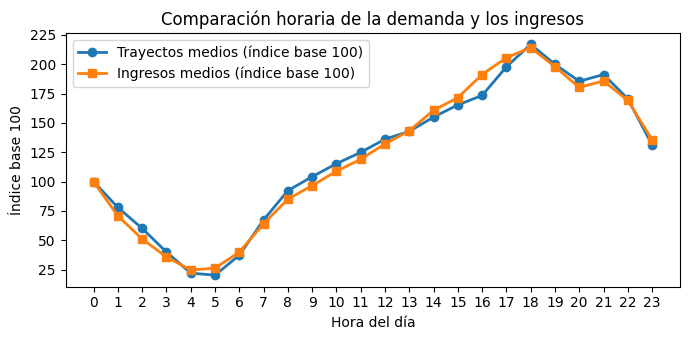

In [11]:
# tabla auxiliar para gráficos horarios
chart_hourly = (
    df_analysis.groupby("pickup_hour_num", as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        revenue_mean=("total_revenue", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean")
    )
)

# normalización base 100 para comparar la forma de ambas series
chart_hourly["trip_count_index"] = (
    chart_hourly["trip_count_mean"] / chart_hourly["trip_count_mean"].iloc[0] * 100
)

chart_hourly["revenue_index"] = (
    chart_hourly["revenue_mean"] / chart_hourly["revenue_mean"].iloc[0] * 100
)

# gráfico comparativo normalizado
plt.figure(figsize=(7, 3.5))

plt.plot(
    chart_hourly["pickup_hour_num"],
    chart_hourly["trip_count_index"],
    marker="o",
    linewidth=2,
    label="Trayectos medios (índice base 100)"
)

plt.plot(
    chart_hourly["pickup_hour_num"],
    chart_hourly["revenue_index"],
    marker="s",
    linewidth=2,
    label="Ingresos medios (índice base 100)"
)

plt.title("Comparación horaria de la demanda y los ingresos")
plt.xlabel("Hora del día")
plt.ylabel("Índice base 100")
plt.xticks(range(24))
plt.legend()
plt.tight_layout()
plt.show()

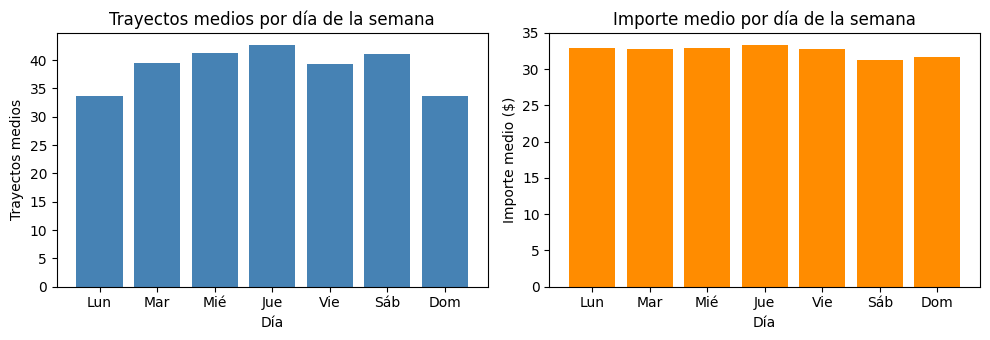

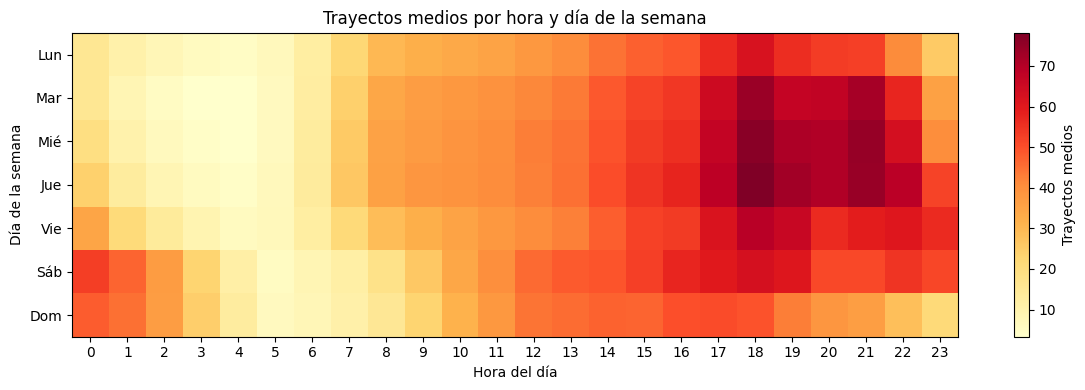

In [12]:
# análisis por día de la semana 

day_labels = {0: "Lun", 1: "Mar", 2: "Mié", 3: "Jue", 4: "Vie", 5: "Sáb", 6: "Dom"}

chart_weekday = (
    df_analysis.groupby("pickup_dayofweek", as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        revenue_mean=("total_revenue", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean"),
        tip_rate_mean=("tip_rate", "mean"),
        airport_trip_share_mean=("airport_trip_share", "mean")
    )
)
chart_weekday["day_label"] = chart_weekday["pickup_dayofweek"].map(day_labels)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].bar(chart_weekday["day_label"], chart_weekday["trip_count_mean"], color="steelblue")
axes[0].set_title("Trayectos medios por día de la semana")
axes[0].set_xlabel("Día")
axes[0].set_ylabel("Trayectos medios")

axes[1].bar(chart_weekday["day_label"], chart_weekday["avg_total_amount_mean"], color="darkorange")
axes[1].set_title("Importe medio por día de la semana")
axes[1].set_xlabel("Día")
axes[1].set_ylabel("Importe medio ($)")

plt.tight_layout()
plt.show()

# heatmap hora × día de la semana

heatmap_data = (
    df_analysis.groupby(["pickup_dayofweek", "pickup_hour_num"])["trip_count"]
    .mean()
    .unstack(level=1) 
)
heatmap_data.index = [day_labels[i] for i in heatmap_data.index]

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(heatmap_data.values, aspect="auto", cmap="YlOrRd")

ax.set_xticks(range(24))
ax.set_xticklabels(range(24))
ax.set_yticks(range(7))
ax.set_yticklabels(heatmap_data.index)
ax.set_title("Trayectos medios por hora y día de la semana")
ax.set_xlabel("Hora del día")
ax.set_ylabel("Día de la semana")
plt.colorbar(im, ax=ax, label="Trayectos medios")
plt.tight_layout()
plt.show()

### Principales hallazgos del bloque temporal

La comparación por día de la semana muestra diferencias moderadas en el volumen medio, pero el mapa de calor permite ver mejor cómo cambia el patrón horario. Entre semana la actividad se intensifica sobre todo al final de la tarde, mientras que el fin de semana gana más peso en horas nocturnas y de madrugada.

## 9. Patrones geográficos y segmentación operativa

En esta sección se analizan las diferencias entre boroughs y zonas de recogida para identificar áreas con más volumen, áreas con mayor valor económico y posibles contrastes entre intensidad operativa y valor medio del trayecto.

In [13]:
# revisión de boroughs
print("boroughs:\n")
print(df_analysis["pickup_borough_grouped"].value_counts(dropna=False))

# resumen por borough
borough_summary = (
    df_analysis.groupby("pickup_borough_grouped", as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        revenue_mean=("total_revenue", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean"),
        avg_trip_distance_mean=("avg_trip_distance", "mean"),
        avg_trip_duration_mean=("avg_trip_duration_min", "mean"),
        airport_trip_share_mean=("airport_trip_share", "mean"),
        tip_rate_mean=("tip_rate", "mean")
    )
    .sort_values("trip_count_mean", ascending=False)
)

# top zonas por volumen
top_zones_volume = (
    df_analysis.groupby(["pickup_borough_grouped", "pickup_zone"], as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        revenue_mean=("total_revenue", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean")
    )
    .sort_values("trip_count_mean", ascending=False)
    .head(15)
)

# top zonas por valor medio
top_zones_value = (
    df_analysis.groupby(["pickup_borough_grouped", "pickup_zone"], as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        revenue_mean=("total_revenue", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean")
    )
    .sort_values("avg_total_amount_mean", ascending=False)
    .head(15)
)

print("\nresumen por borough:\n", borough_summary)
print("\ntop zonas por volumen:\n", top_zones_volume)
print("\ntop zonas por valor medio:\n", top_zones_value)

boroughs:

pickup_borough_grouped
Manhattan         507504
Brooklyn          217388
Queens            203421
Bronx              80275
Sin clasificar     13484
Staten Island       1416
EWR                 1034
Name: count, dtype: int64

resumen por borough:
   pickup_borough_grouped  trip_count_mean  revenue_mean  avg_total_amount_mean  avg_trip_distance_mean  avg_trip_duration_mean  \
3              Manhattan            69.44      1,661.46                  25.74                    3.18                   14.91   
4                 Queens            17.91      1,310.53                  46.91                    7.79                   29.02   
5         Sin clasificar             9.08        308.48                  50.01                    5.46                   17.25   
1               Brooklyn             2.55         81.04                  32.11                    5.93                   31.27   
0                  Bronx             1.42         50.69                  35.87              

In [14]:
# segmentación simple volumen vs valor
zone_segment = (
    df_analysis.groupby(["pickup_borough_grouped", "pickup_zone"], as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean"),
        revenue_mean=("total_revenue", "mean")
    )
)

trip_threshold = zone_segment["trip_count_mean"].median()
value_threshold = zone_segment["avg_total_amount_mean"].median()

def zone_profile(row):
    if row["trip_count_mean"] >= trip_threshold and row["avg_total_amount_mean"] >= value_threshold:
        return "Alto volumen / alto valor"
    elif row["trip_count_mean"] >= trip_threshold and row["avg_total_amount_mean"] < value_threshold:
        return "Alto volumen / bajo valor"
    elif row["trip_count_mean"] < trip_threshold and row["avg_total_amount_mean"] >= value_threshold:
        return "Bajo volumen / alto valor"
    else:
        return "Bajo volumen / bajo valor"

zone_segment["zone_profile"] = zone_segment.apply(zone_profile, axis=1)

print("\nconteo de perfiles de zona:\n")
print(zone_segment["zone_profile"].value_counts())

print("\nejemplos por perfil:\n")
for profile in zone_segment["zone_profile"].unique():
    print(f"\n--- {profile} ---")
    print(
        zone_segment[zone_segment["zone_profile"] == profile]
        .sort_values(["trip_count_mean", "avg_total_amount_mean"], ascending=[False, False])
        .head(5)
    )


conteo de perfiles de zona:

zone_profile
Bajo volumen / alto valor    103
Alto volumen / bajo valor    103
Alto volumen / alto valor     28
Bajo volumen / bajo valor     27
Name: count, dtype: int64

ejemplos por perfil:


--- Bajo volumen / alto valor ---
    pickup_borough_grouped                pickup_zone  trip_count_mean  avg_total_amount_mean  revenue_mean               zone_profile
233                 Queens  Springfield Gardens South             1.49                  70.56        105.05  Bajo volumen / alto valor
207                 Queens                Kew Gardens             1.47                  57.03         84.65  Bajo volumen / alto valor
95                Brooklyn             Sheepshead Bay             1.47                  38.40         56.52  Bajo volumen / alto valor
220                 Queens             Queens Village             1.45                  43.22         62.65  Bajo volumen / alto valor
198                 Queens            Hammels/Arverne             

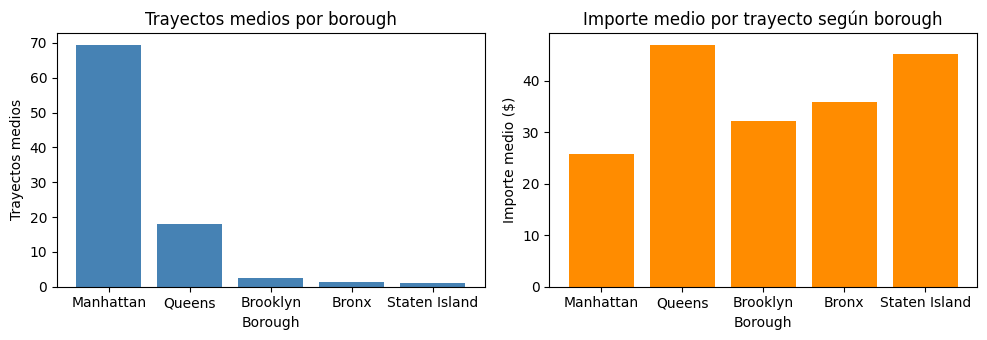

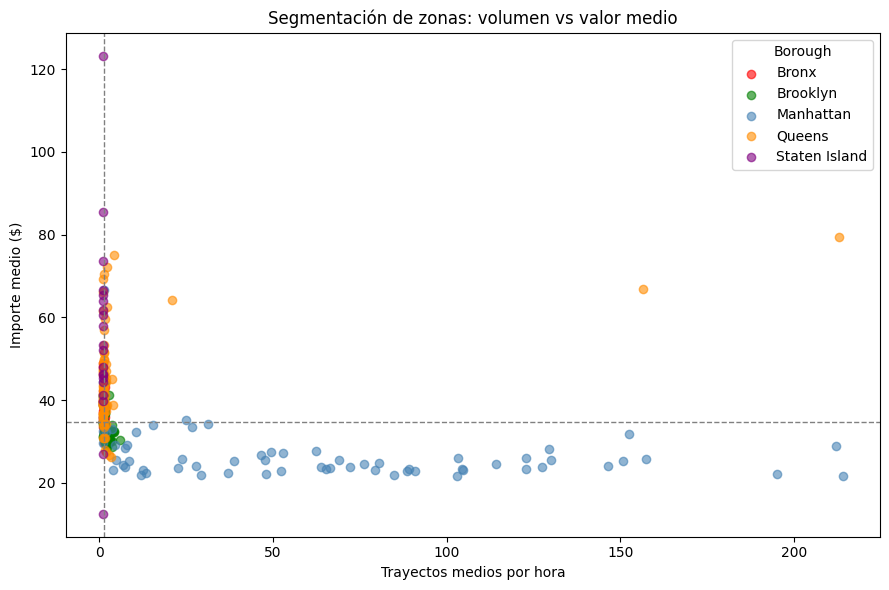

In [15]:
# tabla auxiliar para el gráfico por borough
chart_borough_plot = (
    df_analysis[
        ~df_analysis["pickup_borough_grouped"].isin(["Sin clasificar", "EWR"])
    ]
    .groupby("pickup_borough_grouped", as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean")
    )
    .sort_values("trip_count_mean", ascending=False)
)

# boroughs: volumen y valor lado a lado
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].bar(chart_borough_plot["pickup_borough_grouped"], chart_borough_plot["trip_count_mean"], color="steelblue")
axes[0].set_title("Trayectos medios por borough")
axes[0].set_xlabel("Borough")
axes[0].set_ylabel("Trayectos medios")

axes[1].bar(chart_borough_plot["pickup_borough_grouped"], chart_borough_plot["avg_total_amount_mean"], color="darkorange")
axes[1].set_title("Importe medio por trayecto según borough")
axes[1].set_xlabel("Borough")
axes[1].set_ylabel("Importe medio ($)")

plt.tight_layout()
plt.show()

# scatter volumen vs valor por zona
fig, ax = plt.subplots(figsize=(9, 6))

colors = {
    "Manhattan": "steelblue",
    "Queens": "darkorange",
    "Brooklyn": "green",
    "Bronx": "red",
    "Staten Island": "purple"
}

for borough, group in zone_segment[
    zone_segment["pickup_borough_grouped"].isin(colors.keys())
].groupby("pickup_borough_grouped"):
    ax.scatter(
        group["trip_count_mean"],
        group["avg_total_amount_mean"],
        label=borough,
        alpha=0.6,
        color=colors[borough]
    )

ax.axvline(zone_segment["trip_count_mean"].median(), color="gray", linestyle="--", linewidth=1)
ax.axhline(zone_segment["avg_total_amount_mean"].median(), color="gray", linestyle="--", linewidth=1)
ax.set_title("Segmentación de zonas: volumen vs valor medio")
ax.set_xlabel("Trayectos medios por hora")
ax.set_ylabel("Importe medio ($)")
ax.legend(title="Borough")
plt.tight_layout()
plt.show()

### Principales hallazgos del bloque geográfico

El análisis geográfico muestra una separación clara entre zonas de alto volumen y zonas de alto valor. Manhattan concentra la mayor intensidad operativa del sistema, mientras que Queens destaca más por el valor medio de los trayectos, en buena parte por el peso del tráfico aeroportuario.

La segmentación por perfiles confirma que no todas las zonas cumplen la misma función dentro de la red: algunas actúan como núcleos de alta rotación y otras como áreas de menor frecuencia pero mayor valor económico por trayecto.

## 10. Segmentación de trayectos aeroportuarios

Dado el peso de los aeropuertos en varias de las métricas observadas, en esta sección se compara el comportamiento de los trayectos con componente aeroportuario frente al resto del sistema para evaluar si constituyen un segmento operativo diferenciado.

In [16]:
# comparación entre observaciones con y sin componente aeroportuario
df_airport = df_analysis.copy()

df_airport["airport_segment"] = np.where(
    df_airport["airport_trip_share"] > 0,
    "Con componente aeroportuario",
    "Sin componente aeroportuario"
)

# resumen general del segmento aeroportuario
airport_summary = (
    df_airport.groupby("airport_segment", as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        revenue_mean=("total_revenue", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean"),
        avg_trip_distance_mean=("avg_trip_distance", "mean"),
        avg_trip_duration_mean=("avg_trip_duration_min", "mean"),
        tip_rate_mean=("tip_rate", "mean"),
        card_trip_share_mean=("card_trip_share", "mean"),
        cash_trip_share_mean=("cash_trip_share", "mean")
    )
)

# comparación horaria entre ambos segmentos
airport_hour_summary = (
    df_airport.groupby(["pickup_hour_num", "airport_segment"], as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        revenue_mean=("total_revenue", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean")
    )
)

print("resumen aeropuerto vs no aeropuerto:\n")
print(airport_summary)

print("\nresumen horario por segmento aeroportuario:\n")
print(airport_hour_summary)


resumen aeropuerto vs no aeropuerto:

                airport_segment  trip_count_mean  revenue_mean  avg_total_amount_mean  avg_trip_distance_mean  avg_trip_duration_mean  \
0  Con componente aeroportuario           118.41      8,454.19                  64.74                   10.23                   29.91   
1  Sin componente aeroportuario            36.24        879.50                  31.50                    4.93                   22.76   

   tip_rate_mean  card_trip_share_mean  cash_trip_share_mean  
0           0.72                  0.77                  0.18  
1           0.42                  0.61                  0.12  

resumen horario por segmento aeroportuario:

    pickup_hour_num               airport_segment  trip_count_mean  revenue_mean  avg_total_amount_mean
0                 0  Con componente aeroportuario            98.52      6,971.25                  62.90
1                 0  Sin componente aeroportuario            28.60        675.25                  27.34
2  

In [17]:
# zonas con mayor proporción aeroportuaria con volumen mínimo
airport_share_top_filtered = (
    df_analysis[df_analysis["airport_trip_share"] > 0]
    .groupby(["pickup_borough_grouped", "pickup_zone"], as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        revenue_mean=("total_revenue", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean"),
        airport_trip_share_mean=("airport_trip_share", "mean")
    )
    .query("trip_count_mean >= 5")
    .sort_values(
        ["airport_trip_share_mean", "trip_count_mean"],
        ascending=[False, False]
    )
    .head(15)
)

print("zonas con mayor proporción aeroportuaria (volumen mínimo):\n")
print(airport_share_top_filtered)

zonas con mayor proporción aeroportuaria (volumen mínimo):

    pickup_borough_grouped                     pickup_zone  trip_count_mean  revenue_mean  avg_total_amount_mean  airport_trip_share_mean
153                 Queens               LaGuardia Airport           156.60     10,732.51                  66.79                     0.99
147                 Queens                     JFK Airport           212.99     17,605.43                  79.33                     0.95
136                 Queens                   East Elmhurst            21.61      1,433.30                  65.19                     0.83
51                Brooklyn                        Red Hook             5.33        396.72                  80.52                     0.61
62               Manhattan                   Alphabet City             5.00        175.50                  58.50                     0.56
68               Manhattan                       Chinatown             8.50        346.08                  35.58

### Comparación del segmento aeroportuario

Para sintetizar el comportamiento diferencial del segmento aeroportuario, se comparan sus principales métricas operativas y económicas frente al resto del sistema. Esta visualización resume de forma compacta el peso relativo de ambos perfiles.

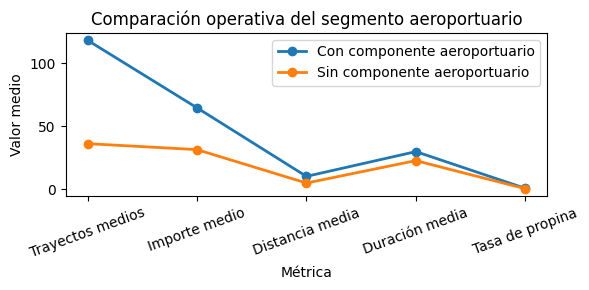

In [18]:
# tabla auxiliar para el gráfico aeroportuario
chart_airport_plot = (
    df_analysis.assign(
        airport_segment=np.where(
            df_analysis["airport_trip_share"] > 0,
            "Con componente aeroportuario",
            "Sin componente aeroportuario"
        )
    )
    .groupby("airport_segment", as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean"),
        avg_trip_distance_mean=("avg_trip_distance", "mean"),
        avg_trip_duration_mean=("avg_trip_duration_min", "mean"),
        tip_rate_mean=("tip_rate", "mean")
    )
)

# pasamos a formato largo para comparar métricas
chart_airport_long = chart_airport_plot.melt(
    id_vars="airport_segment",
    var_name="metric",
    value_name="value"
)

# etiquetas más limpias
metric_labels = {
    "trip_count_mean": "Trayectos medios",
    "avg_total_amount_mean": "Importe medio",
    "avg_trip_distance_mean": "Distancia media",
    "avg_trip_duration_mean": "Duración media",
    "tip_rate_mean": "Tasa de propina"
}
chart_airport_long["metric"] = chart_airport_long["metric"].map(metric_labels)

# gráfico
plt.figure(figsize=(6, 3))

for segment in chart_airport_long["airport_segment"].unique():
    subset = chart_airport_long[chart_airport_long["airport_segment"] == segment]
    plt.plot(
        subset["metric"],
        subset["value"],
        marker="o",
        linewidth=2,
        label=segment
    )

plt.title("Comparación operativa del segmento aeroportuario")
plt.xlabel("Métrica")
plt.ylabel("Valor medio")
plt.xticks(rotation=20)
plt.legend()
plt.tight_layout()
plt.show()

### Principales hallazgos del bloque aeroportuario

Los trayectos con componente aeroportuario forman un segmento claramente diferenciado del resto del sistema. En promedio, presentan más volumen, más ingresos, mayor importe medio, mayor distancia y mayor duración, además de una mayor proporción de pagos con tarjeta y una tasa de propina más alta.

Este comportamiento no se limita a unas pocas horas concretas, sino que se mantiene a lo largo del día. Los aeropuertos, especialmente JFK y LaGuardia, aparecen así como nodos estratégicos dentro de la operación total del sistema.

## 11. Condiciones meteorológicas como contexto operativo

En esta sección se analiza si la lluvia y la oscuridad modifican algunos de los patrones ya observados en la demanda y en el valor económico de los trayectos. El objetivo no es situar la meteorología como explicación principal, sino comprobar en qué medida actúa como factor contextual sobre segmentos operativos ya identificados.

In [19]:
# copia de trabajo para análisis meteorológico
df_weather = df_analysis.copy()

# resumen simple por lluvia
rain_summary = (
    df_weather.groupby("rain_flag", as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        revenue_mean=("total_revenue", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean"),
        avg_trip_distance_mean=("avg_trip_distance", "mean"),
        avg_trip_duration_mean=("avg_trip_duration_min", "mean"),
        airport_trip_share_mean=("airport_trip_share", "mean"),
        tip_rate_mean=("tip_rate", "mean")
    )
)

# resumen por lluvia intensa
heavy_rain_summary = (
    df_weather.groupby("heavy_rain_flag", as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        revenue_mean=("total_revenue", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean"),
        avg_trip_distance_mean=("avg_trip_distance", "mean"),
        avg_trip_duration_mean=("avg_trip_duration_min", "mean"),
        airport_trip_share_mean=("airport_trip_share", "mean"),
        tip_rate_mean=("tip_rate", "mean")
    )
)

# resumen por oscuridad
dark_summary = (
    df_weather.groupby("is_dark", as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        revenue_mean=("total_revenue", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean"),
        avg_trip_distance_mean=("avg_trip_distance", "mean"),
        avg_trip_duration_mean=("avg_trip_duration_min", "mean"),
        airport_trip_share_mean=("airport_trip_share", "mean"),
        tip_rate_mean=("tip_rate", "mean")
    )
)

print("resumen por lluvia:\n")
print(rain_summary)

print("\nresumen por lluvia intensa:\n")
print(heavy_rain_summary)

print("\nresumen por oscuridad:\n")
print(dark_summary)

resumen por lluvia:

   rain_flag  trip_count_mean  revenue_mean  avg_total_amount_mean  avg_trip_distance_mean  avg_trip_duration_mean  \
0          0            38.53      1,105.37                  32.54                    5.11                   23.00   
1          1            40.85      1,142.74                  32.16                    4.92                   22.61   

   airport_trip_share_mean  tip_rate_mean  
0                     0.02           0.43  
1                     0.02           0.43  

resumen por lluvia intensa:

   heavy_rain_flag  trip_count_mean  revenue_mean  avg_total_amount_mean  avg_trip_distance_mean  avg_trip_duration_mean  \
0                0            38.57      1,106.03                  32.53                    5.10                   22.99   
1                1            41.19      1,147.45                  32.14                    4.90                   22.55   

   airport_trip_share_mean  tip_rate_mean  
0                     0.02           0.43  
1

In [20]:
# interacción entre lluvia y segmento aeroportuario
df_weather["airport_segment"] = np.where(
    df_weather["airport_trip_share"] > 0,
    "Con componente aeroportuario",
    "Sin componente aeroportuario"
)

rain_airport_summary = (
    df_weather.groupby(["rain_flag", "airport_segment"], as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        revenue_mean=("total_revenue", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean"),
        avg_trip_distance_mean=("avg_trip_distance", "mean"),
        avg_trip_duration_mean=("avg_trip_duration_min", "mean"),
        tip_rate_mean=("tip_rate", "mean")
    )
)

dark_airport_summary = (
    df_weather.groupby(["is_dark", "airport_segment"], as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        revenue_mean=("total_revenue", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean"),
        avg_trip_distance_mean=("avg_trip_distance", "mean"),
        avg_trip_duration_mean=("avg_trip_duration_min", "mean"),
        tip_rate_mean=("tip_rate", "mean")
    )
)

print("resumen lluvia x segmento aeroportuario:\n")
print(rain_airport_summary)

print("\nresumen oscuridad x segmento aeroportuario:\n")
print(dark_airport_summary)

resumen lluvia x segmento aeroportuario:

   rain_flag               airport_segment  trip_count_mean  revenue_mean  avg_total_amount_mean  avg_trip_distance_mean  \
0          0  Con componente aeroportuario           118.97      8,498.33                  64.75                   10.22   
1          0  Sin componente aeroportuario            36.02        874.56                  31.53                    4.95   
2          1  Con componente aeroportuario           111.23      7,892.71                  64.51                   10.29   
3          1  Sin componente aeroportuario            38.67        933.70                  31.16                    4.75   

   avg_trip_duration_mean  tip_rate_mean  
0                   29.84           0.72  
1                   22.78           0.42  
2                   30.54           0.72  
3                   22.36           0.42  

resumen oscuridad x segmento aeroportuario:

   is_dark               airport_segment  trip_count_mean  revenue_mean  avg

### Comparación entre horario diurno y horario nocturno

Como síntesis del bloque meteorológico, se compara el comportamiento medio del sistema entre horario diurno y horario nocturno. Esta visualización permite observar si la intensidad operativa y el valor medio del trayecto cambian según este contexto.

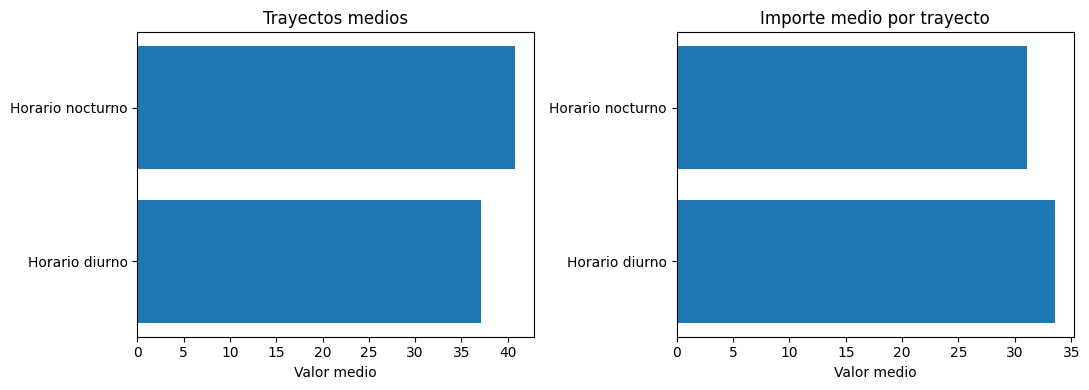

In [21]:
# tabla auxiliar para el gráfico de oscuridad
chart_dark_plot = (
    df_analysis.groupby("is_dark", as_index=False)
    .agg(
        trip_count_mean=("trip_count", "mean"),
        avg_total_amount_mean=("avg_total_amount", "mean")
    )
)

# etiquetas más legibles
chart_dark_plot["dark_label"] = chart_dark_plot["is_dark"].map({
    0: "Horario diurno",
    1: "Horario nocturno"
})

# gráficos compactos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# gráfico 1: trayectos medios
axes[0].barh(
    chart_dark_plot["dark_label"],
    chart_dark_plot["trip_count_mean"]
)
axes[0].set_title("Trayectos medios")
axes[0].set_xlabel("Valor medio")
axes[0].set_ylabel("")

# gráfico 2: importe medio
axes[1].barh(
    chart_dark_plot["dark_label"],
    chart_dark_plot["avg_total_amount_mean"]
)
axes[1].set_title("Importe medio por trayecto")
axes[1].set_xlabel("Valor medio")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

### Principales hallazgos del bloque meteorológico

La meteorología actúa como factor contextual, pero no como explicación principal del comportamiento del sistema. La lluvia modifica algunos indicadores de forma moderada, aunque su efecto es menor que el de variables como la hora, la localización o el segmento aeroportuario.

La oscuridad resulta más informativa que la lluvia. Durante las horas nocturnas aumenta la intensidad operativa y la recaudación, mientras que el valor medio, la distancia y la duración tienden a reducirse, lo que apunta a un patrón de movilidad más denso y más urbano en esas franjas.

## 12. Análisis estadístico

Para complementar el análisis descriptivo, en esta sección se realizan comparaciones simples entre grupos con el objetivo de comprobar si algunas diferencias observadas en variables como la lluvia o la oscuridad se sostienen también desde un punto de vista estadístico.

In [22]:
from scipy.stats import mannwhitneyu

# copia para análisis estadístico
df_stats = df_analysis.copy()

# función auxiliar para contraste no paramétrico
def mannwhitney_test(df, group_col, value_col, group_a, group_b):
    subset = df[[group_col, value_col]].dropna().copy()

    a = subset.loc[subset[group_col] == group_a, value_col]
    b = subset.loc[subset[group_col] == group_b, value_col]

    stat, p_value = mannwhitneyu(a, b, alternative="two-sided")

    return pd.DataFrame({
        "variable": [value_col],
        "grupo_a": [group_a],
        "grupo_b": [group_b],
        "media_a": [a.mean()],
        "media_b": [b.mean()],
        "mediana_a": [a.median()],
        "mediana_b": [b.median()],
        "n_a": [len(a)],
        "n_b": [len(b)],
        "estadístico_u": [stat],
        "p_value": [p_value]
    })

# pruebas seleccionadas
test_rain_trip_count = mannwhitney_test(df_stats, "rain_flag", "trip_count", 0, 1)
test_rain_revenue = mannwhitney_test(df_stats, "rain_flag", "total_revenue", 0, 1)

test_dark_trip_count = mannwhitney_test(df_stats, "is_dark", "trip_count", 0, 1)
test_dark_avg_total = mannwhitney_test(df_stats, "is_dark", "avg_total_amount", 0, 1)

stats_results = pd.concat([
    test_rain_trip_count,
    test_rain_revenue,
    test_dark_trip_count,
    test_dark_avg_total
], ignore_index=True)

print("resultados de contraste:\n")
print(stats_results)

resultados de contraste:

           variable  grupo_a  grupo_b  media_a  media_b  mediana_a  mediana_b     n_a     n_b      estadístico_u  p_value
0        trip_count        0        1    38.53    40.85       4.00       4.00  941754   80696  37,741,889,712.00     0.00
1     total_revenue        0        1 1,105.37 1,142.74     135.22     138.47  941754   80696  37,904,537,396.00     0.25
2        trip_count        0        1    37.16    40.83       4.00       5.00  588733  433717 123,066,870,622.00     0.00
3  avg_total_amount        0        1    33.55    31.09      27.32      24.70  588733  433717 144,028,932,146.00     0.00


### Lectura de los resultados estadísticos

Los contrastes muestran que la lluvia tiene una asociación estadísticamente significativa con el número de trayectos por hora, si bien la diferencia observada es reducida en términos prácticos. En cambio, no se detecta una diferencia estadísticamente clara en los ingresos horarios entre horas con lluvia y horas sin lluvia.

La oscuridad presenta un patrón más consistente. Las horas nocturnas o sin luz natural concentran una mayor intensidad operativa, medida por el número de trayectos, pero al mismo tiempo muestran un menor importe medio por trayecto. Esto refuerza la idea de que la oscuridad actúa como un factor de contexto más relevante que la lluvia dentro del sistema, sin que deje de ser secundaria frente a variables como la franja horaria, la localización o el componente aeroportuario.

## 13. Conclusiones e interpretación de negocio

A lo largo del análisis queda claro que las diferencias más marcadas no vienen tanto por la meteorología como por la combinación de hora, zona y tipo de trayecto.

Manhattan sigue siendo el núcleo más evidente, porque concentra gran parte de la actividad y del volumen operativo. El importe medio por trayecto, en cambio, destaca más en Queens, sobre todo por el peso de los viajes ligados al aeropuerto, que tienden a ser más largos y más caros.

Los trayectos ligados al aeropuerto muestran el rasgo más distintivo de todo el proyecto. Suelen ser más largos, duran más y generan importes notablemente más altos, con una regularidad que se mantiene a lo largo del día.

La lluvia puede introducir variaciones en ciertas métricas, pero no reorganiza el sistema ni cambia su lógica principal. La oscuridad resulta más útil como variable de contexto: durante las horas nocturnas aumenta la actividad, con la particularidad de que el importe medio por trayecto baja ligeramente.

En la práctica se mezclan dos tipos de demanda bastante distintos: la movilidad urbana más densa y continua, concentrada sobre todo en Manhattan, y los trayectos aeroportuarios, más largos, más caros y mucho más visibles en Queens.

### Limitaciones del análisis

Este proyecto trabaja con datos agregados por hora y zona de recogida, lo que permite ver patrones operativos con bastante claridad, pero también reduce el detalle de cada trayecto individual. Además, algunas zonas aparecen como especiales o sin clasificar dentro de la tabla auxiliar geográfica, y una parte pequeña de la información meteorológica presenta valores ausentes. Por último, el análisis es descriptivo y comparativo, por lo que los resultados no deben interpretarse como relaciones causales.

In [23]:
# exportación del dataset final para dashboard
output_dir = Path("data/processed")
output_dir.mkdir(parents=True, exist_ok=True)

df_analysis.to_csv(
    output_dir / "taxi_analysis_2024_final.csv",
    index=False,
    decimal=".",
    sep=",",
    float_format="%.4f"
)
print("Exportado correctamente:", df_analysis.shape)

Exportado correctamente: (1024522, 35)
